In [3]:
!pip install deepxde  # already installed

In [4]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

## 1D heat equation

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$$

PINN residual (should be zero in the interior):

$$\frac{\partial u}{\partial t} - \alpha \frac{\partial^2 u}{\partial x^2} = 0$$

- **Space:** $x \in [-1, 1]$
- **Time:** $t \in [0, 1]$
- **Diffusivity:** $\alpha$ (set below)

In [5]:
X_MIN, X_MAX = 0.0, 1.0
T_MIN, T_MAX = 0.0, 5.0
ALPHA = 0.01  # thermal diffusivity


def heat_pde(x, y):
    du_t = dde.grad.jacobian(y, x, i=0, j=1)
    du_xx = dde.grad.hessian(y, x, i=0, j=0)
    return du_t - ALPHA * du_xx

## Domain

In [6]:
space = dde.geometry.Interval(X_MIN, X_MAX)
time = dde.geometry.TimeDomain(T_MIN, T_MAX)
geomtime = dde.geometry.GeometryXTime(space, time)

## Boundary and initial conditions

- **Dirichlet BC:** $u = 0$ on $x = -1$ and $x = 1$
- **IC:** $u(x, 0) = \sin(\pi x)$

In [7]:
def boundary_value(_):
    return 0


def is_boundary(_, on_boundary):
    return on_boundary


bc = dde.DirichletBC(geomtime, boundary_value, is_boundary)


def initial_condition(x):
    return np.sin(np.pi * x[:, 0:1])

def on_initial(x, on_initial):
    return on_initial

# DeepXDE calls the IC predicate per point (1D [x, t]), not on batches.
# Use geometry's on_initial flag, same as Burger_Equation_PINN.ipynb.
# ic = dde.IC(geomtime, initial_condition, lambda x, on_initial: on_initial)

ic = dde.IC(geomtime, initial_condition, on_initial)

In [11]:
data = dde.data.TimePDE(
    geomtime,
    heat_pde,
    [bc, ic],
    num_domain=2540,
    num_boundary=80,
    num_initial=160,
)

net = dde.nn.FNN([2] + [64] * 4 + [1], "tanh", "Glorot normal")
model = dde.Model(data, net)
model.compile("adam", lr=1e-3)
losshistory, train_state = model.train(iterations=20000)

# Then fine-tune with smaller lr
# model.compile("L-BFGS")
# losshistory, train_state = model.train()
# print("PDE residual loss:", losshistory.loss_train[-1])



Compiling model...
'compile' took 0.003629 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [5.70e-02, 6.21e-01, 6.85e-01]    [5.70e-02, 6.21e-01, 6.85e-01]    []  
1000      [1.88e-04, 2.69e-05, 9.25e-05]    [1.88e-04, 2.69e-05, 9.25e-05]    []  
2000      [6.79e-05, 5.12e-04, 1.25e-04]    [6.79e-05, 5.12e-04, 1.25e-04]    []  
3000      [3.16e-05, 1.39e-06, 6.49e-06]    [3.16e-05, 1.39e-06, 6.49e-06]    []  
4000      [1.66e-05, 8.17e-07, 3.51e-06]    [1.66e-05, 8.17e-07, 3.51e-06]    []  
5000      [9.18e-06, 5.00e-07, 1.47e-06]    [9.18e-06, 5.00e-07, 1.47e-06]    []  
6000      [7.76e-06, 1.99e-06, 1.39e-06]    [7.76e-06, 1.99e-06, 1.39e-06]    []  
7000      [5.48e-06, 2.72e-07, 8.22e-07]    [5.48e-06, 2.72e-07, 8.22e-07]    []  
8000      [5.33e-06, 4.04e-05, 1.32e-05]    [5.33e-06, 4.04e-05, 1.32e-05]    []  
9000      [9.19e-06, 1.88e-04, 1.99e-05]    [9.19e-06, 1.88e-04, 1.99e-05]    []  
10000     [2.55

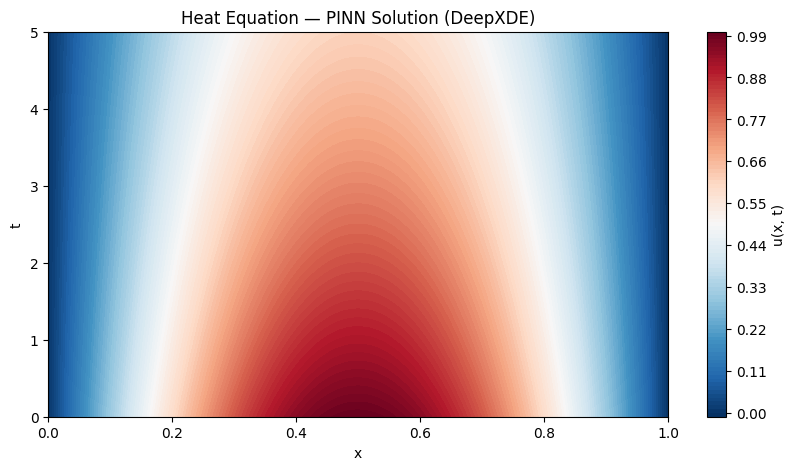

In [12]:
# ── 8. Visualize the Solution ──────────────────────────────────────
X = np.linspace(0, 1, 256)
T = np.linspace(0, 5, 100)
XX, TT = np.meshgrid(X, T)

# Predict u(x,t) over the entire grid
XT = np.column_stack([XX.ravel(), TT.ravel()])
u_pred = model.predict(XT).reshape(100, 256)

plt.figure(figsize=(10, 5))
plt.contourf(XX, TT, u_pred, levels=100, cmap="RdBu_r")
plt.colorbar(label="u(x, t)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Heat Equation — PINN Solution (DeepXDE)")
plt.show()

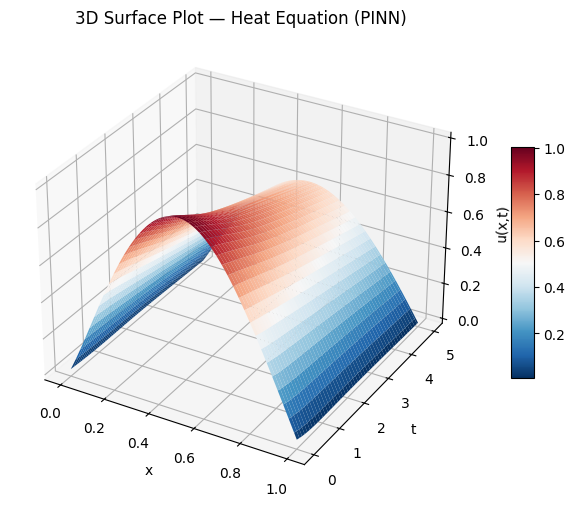

In [10]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(XX, TT, u_pred, cmap="RdBu_r")  # <-- match here

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_zlabel("u(x,t)")
ax.set_title("3D Surface Plot — Heat Equation (PINN)")

plt.show()